**Name:** Beiwei Niu  
**GitHub Username:** jackson666888007  
**USC ID:** 8920677336

In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler

%matplotlib inline

## 1. Combined Cycle Power Plant Data Set
### 1(a) Load Data

In [22]:
data_path = Path("../data/CCPP/Folds5x2_pp.xlsx")

assert data_path.exists(), f"Data file not found: {data_path.resolve()}"

data = pd.read_excel(data_path, sheet_name=0)
data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### 1(b) Exploring Data
#### 1(b)(i) Dataset Dimensions and Variables

In [23]:
print(f"Number of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")
print("\nColumn data types:")
display(data.dtypes.to_frame("Data Type"))

Number of rows: 9568
Number of columns: 5

Column data types:


,Data Type
AT,float64
V,float64
AP,float64
RH,float64
PE,float64


The dataset has 9,568 rows and 5 columns.  
Each row represents one hourly observation.  
AT, V, AP, and RH are predictors, and PE is the response.

#### 1(b)(ii) Pairwise Scatterplots

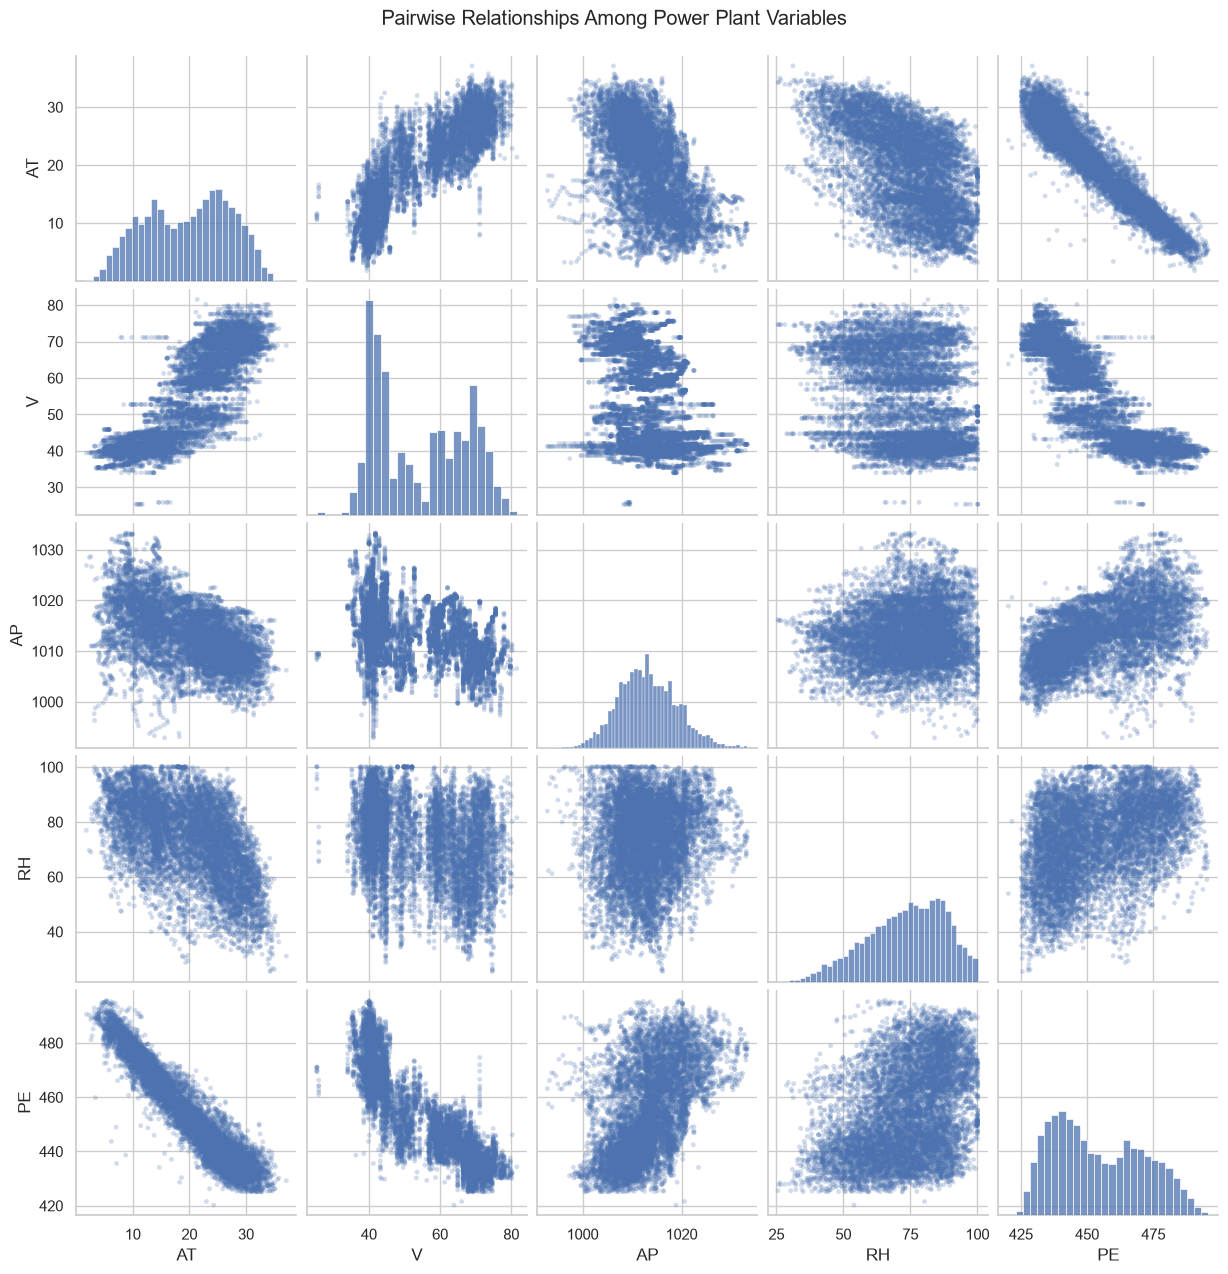

In [24]:
sns.set_theme(style="whitegrid")

pair_plot = sns.pairplot(
    data,
    diag_kind="hist",
    plot_kws={
        "alpha": 0.25,
        "s": 12,
        "edgecolor": "none"
    }
)

pair_plot.fig.suptitle(
    "Pairwise Relationships Among Power Plant Variables",
    y=1.02
)

plt.show()

There is a strong negative correlation between PE and both AT and V.
Its relationship with AP and RH is positive but relatively weak.
There is also a strong positive correlation between AT and V.
Some of the relationships exhibit a slight non-linear characteristic.

#### 1(b)(iii) Descriptive Statistics

In [25]:
summary_statistics = pd.DataFrame({
    "Mean": data.mean(),
    "Median": data.median(),
    "Range": data.max() - data.min(),
    "First Quartile (Q1)": data.quantile(0.25),
    "Third Quartile (Q3)": data.quantile(0.75),
    "IQR": data.quantile(0.75) - data.quantile(0.25)
})

summary_statistics.round(2)

,Mean,Median,Range,First Quartile (Q1),Third Quartile (Q3),IQR
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


### 1(c) Simple Linear Regression

In [26]:
predictors = ["AT", "V", "AP", "RH"]

simple_models = {}
simple_results = []

for predictor in predictors:
    X = sm.add_constant(data[[predictor]])
    model = sm.OLS(data["PE"], X).fit()
    
    simple_models[predictor] = model
    
    simple_results.append({
        "Predictor": predictor,
        "Intercept": model.params["const"],
        "Coefficient": model.params[predictor],
        "P-value": (
            "< 0.001"
            if model.pvalues[predictor] < 0.001
            else f"{model.pvalues[predictor]:.3f}"
        ),
        "R-squared": model.rsquared
    })

simple_results = pd.DataFrame(simple_results).set_index("Predictor")
simple_results.round(3)

,Intercept,Coefficient,P-value,R-squared
Predictor,,,,
AT,497.034,-2.171,< 0.001,0.899
V,517.802,-1.168,< 0.001,0.757
AP,-1055.261,1.490,< 0.001,0.269
RH,420.962,0.456,< 0.001,0.152


All four predictors were significant (p < 0.001).
The coefficients of AT and V were negative, while those of AP and RH were positive.
The R² value for AT was the highest, followed by V.

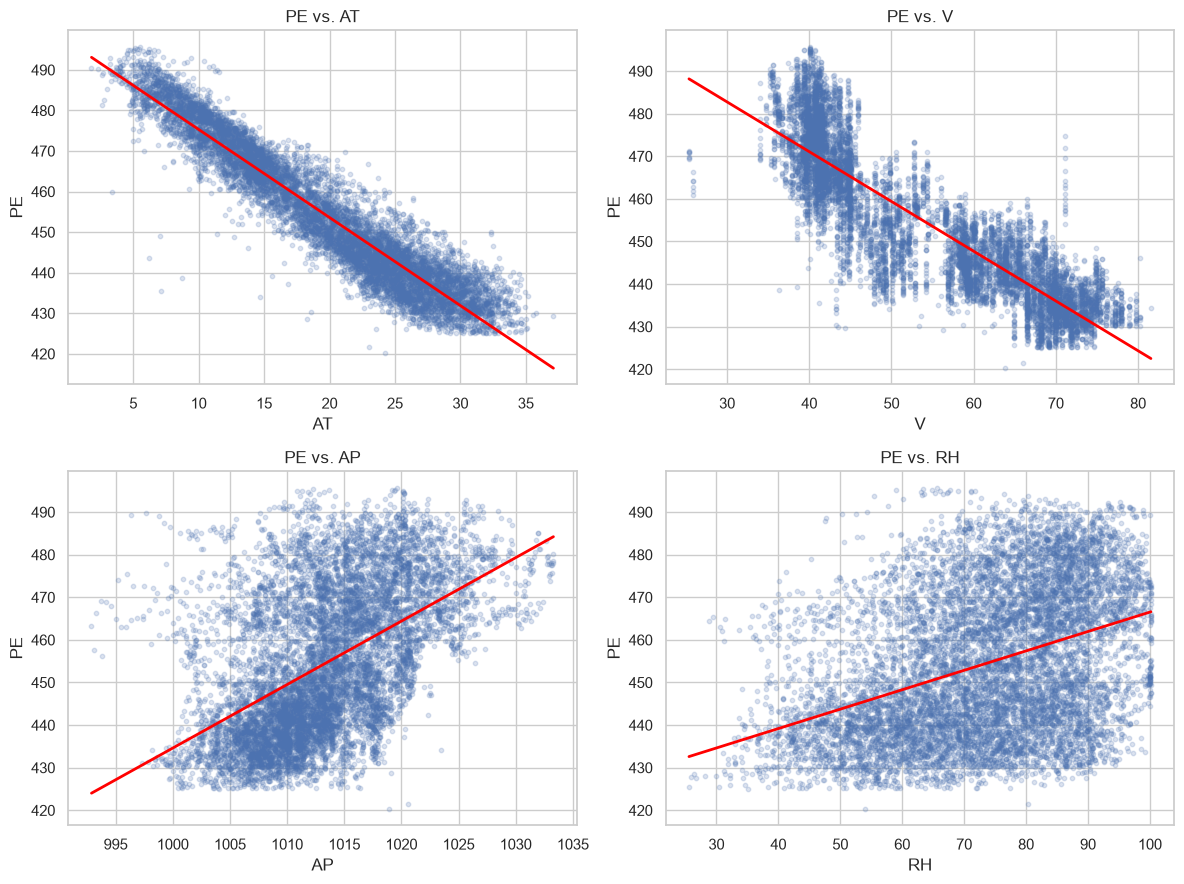

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for predictor, ax in zip(predictors, axes):
    sns.regplot(
        data=data,
        x=predictor,
        y="PE",
        ax=ax,
        ci=None,
        scatter_kws={"alpha": 0.20, "s": 10},
        line_kws={"color": "red", "linewidth": 2}
    )
    ax.set_title(f"PE vs. {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

In [28]:
outlier_diagnostics = []

for predictor, model in simple_models.items():
    influence = model.get_influence()
    
    studentized_residuals = influence.resid_studentized_external
    cooks_distance = influence.cooks_distance[0]
    
    outlier_diagnostics.append({
        "Predictor": predictor,
        "|Studentized Residual| > 3": np.sum(
            np.abs(studentized_residuals) > 3
        ),
        "Maximum Cook's Distance": cooks_distance.max()
    })

outlier_diagnostics = pd.DataFrame(
    outlier_diagnostics
).set_index("Predictor")

outlier_diagnostics.round(4)

,|Studentized Residual| > 3,Maximum Cook's Distance
Predictor,,
AT,42,0.0143
V,33,0.0032
AP,30,0.0082
RH,2,0.0021


The studentized residuals for some of the observations are relatively large.
However, all the Cook distances are far below 1.
No obvious data errors were found, so no observations were deleted.

### 1(d) Multiple Linear Regression

In [29]:
X_multiple = sm.add_constant(data[predictors])

multiple_model = sm.OLS(
    data["PE"],
    X_multiple
).fit()

multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "Standard Error": multiple_model.bse,
    "t-statistic": multiple_model.tvalues,
    "P-value": multiple_model.pvalues
})

print(f"R-squared: {multiple_model.rsquared:.3f}")
print(f"Adjusted R-squared: {multiple_model.rsquared_adj:.3f}")

multiple_results.round(4)

R-squared: 0.929
Adjusted R-squared: 0.929


,Coefficient,Standard Error,t-statistic,P-value
const,454.6093,9.7485,46.6337,0.0
AT,-1.9775,0.0153,-129.3420,0.0
V,-0.2339,0.0073,-32.1221,0.0
AP,0.0621,0.0095,6.5641,0.0
RH,-0.1581,0.0042,-37.9185,0.0


The model explains 92.9% of the variation in PE.  
All four predictor variables are significant (p < 0.001).
Therefore, for AT, V, AP and RH, the null hypothesis H₀: βⱼ = 0 is rejected.
When other predictor variables remain unchanged, the coefficients of AT, V and RH are negative, while the coefficient of AP is positive.

### 1(e) Comparison of Simple and Multiple Regression Coefficients

In [30]:
coefficient_comparison = pd.DataFrame({
    "Simple Regression": [
        simple_models[predictor].params[predictor]
        for predictor in predictors
    ],
    "Multiple Regression": [
        multiple_model.params[predictor]
        for predictor in predictors
    ]
}, index=predictors)

coefficient_comparison.index.name = "Predictor"
coefficient_comparison.round(3)

,Simple Regression,Multiple Regression
Predictor,,
AT,-2.171,-1.978
V,-1.168,-0.234
AP,1.490,0.062
RH,0.456,-0.158


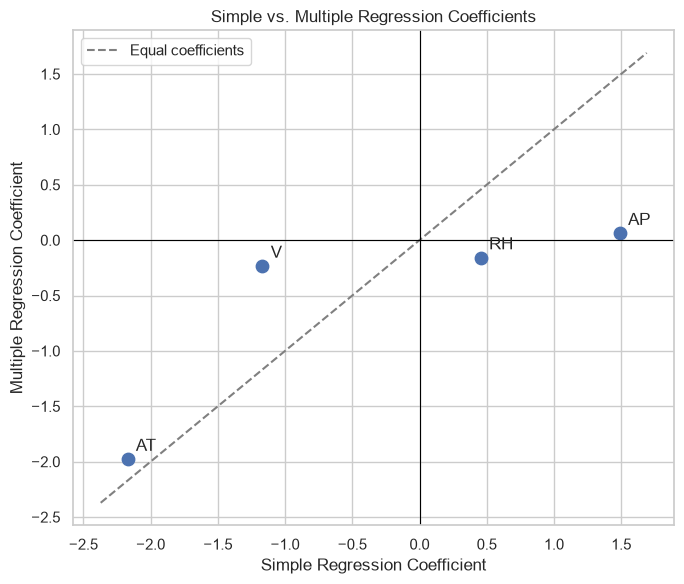

In [31]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    coefficient_comparison["Simple Regression"],
    coefficient_comparison["Multiple Regression"],
    s=80
)

for predictor, row in coefficient_comparison.iterrows():
    ax.annotate(
        predictor,
        (
            row["Simple Regression"],
            row["Multiple Regression"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

lower = coefficient_comparison.min().min() - 0.2
upper = coefficient_comparison.max().max() + 0.2

ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    color="gray",
    label="Equal coefficients"
)

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_xlabel("Simple Regression Coefficient")
ax.set_ylabel("Multiple Regression Coefficient")
ax.set_title("Simple vs. Multiple Regression Coefficients")
ax.legend()

plt.tight_layout()
plt.show()

The AT coefficient has changed only slightly.
The V and AP coefficients have become much smaller.
The RH coefficient has changed from positive to negative.
These differences reflect the correlations among the predictor variables.

### 1(f) Nonlinear Associations

In [32]:
cubic_models = {}
nonlinear_results = []

for predictor in predictors:
    x_centered = data[predictor] - data[predictor].mean()
    
    X_cubic = pd.DataFrame({
        predictor: x_centered,
        f"{predictor}^2": x_centered ** 2,
        f"{predictor}^3": x_centered ** 3
    })
    
    X_cubic = sm.add_constant(X_cubic)
    
    cubic_model = sm.OLS(
        data["PE"],
        X_cubic
    ).fit()
    
    cubic_models[predictor] = cubic_model
    
    f_statistic, joint_p_value, _ = (
        cubic_model.compare_f_test(simple_models[predictor])
    )
    
    quadratic_p = cubic_model.pvalues[f"{predictor}^2"]
    cubic_p = cubic_model.pvalues[f"{predictor}^3"]
    
    nonlinear_results.append({
        "Predictor": predictor,
        "Quadratic p-value": (
            "< 0.001"
            if quadratic_p < 0.001
            else f"{quadratic_p:.3f}"
        ),
        "Cubic p-value": (
            "< 0.001"
            if cubic_p < 0.001
            else f"{cubic_p:.3f}"
        ),
        "Joint F-statistic": f_statistic,
        "Joint p-value": (
            "< 0.001"
            if joint_p_value < 0.001
            else f"{joint_p_value:.3f}"
        ),
        "R-squared": cubic_model.rsquared
    })

nonlinear_results = pd.DataFrame(
    nonlinear_results
).set_index("Predictor")

nonlinear_results.round(3)

,Quadratic p-value,Cubic p-value,Joint F-statistic,Joint p-value,R-squared
Predictor,,,,,
AT,< 0.001,< 0.001,701.967,< 0.001,0.912
V,< 0.001,0.014,393.314,< 0.001,0.775
AP,< 0.001,< 0.001,195.886,< 0.001,0.298
RH,0.101,< 0.001,10.189,< 0.001,0.154


The joint test showed significant results for all four predictors (p < 0.001).
Therefore, AT, V, AP, and RH all demonstrated evidence of non-linear associations with PE.
For RH, the quadratic term was not significant, but the cubic term was significant.

### 1(g) Pairwise Interaction Effects

In [33]:
interaction_formula = "PE ~ (AT + V + AP + RH) ** 2"

interaction_model = smf.ols(
    interaction_formula,
    data=data
).fit()

interaction_terms = [
    "AT:V",
    "AT:AP",
    "AT:RH",
    "V:AP",
    "V:RH",
    "AP:RH"
]

interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_terms],
    "P-value": interaction_model.pvalues[interaction_terms]
})

interaction_results["Significant at 0.05"] = (
    interaction_results["P-value"] < 0.05
)

interaction_results_display = interaction_results.copy()

interaction_results_display["P-value"] = (
    interaction_results_display["P-value"].map(
        lambda p: "< 0.001" if p < 0.001 else f"{p:.3f}"
    )
)

print(f"R-squared: {interaction_model.rsquared:.3f}")

interaction_results_display.round(4)

R-squared: 0.936


,Coefficient,P-value,Significant at 0.05
AT:V,0.0210,< 0.001,True
AT:AP,0.0018,0.452,False
AT:RH,-0.0052,< 0.001,True
V:AP,0.0068,< 0.001,True
V:RH,0.0008,0.086,False
AP:RH,-0.0016,0.034,True


AT×V, AT×RH, V×AP and AP×RH are significant at the α = 0.05 level.
AT×AP and V×RH are not significant.
To maintain the hierarchical structure of the model, all main effects were retained.

### 1(h) Model Improvement and MSE Comparison

In [34]:
train_data, test_data = train_test_split(
    data,
    test_size=0.30,
    random_state=42
)

X_train_base = sm.add_constant(
    train_data[predictors],
    has_constant="add"
)

X_test_base = sm.add_constant(
    test_data[predictors],
    has_constant="add"
)

baseline_model = sm.OLS(
    train_data["PE"],
    X_train_base
).fit()

baseline_train_predictions = baseline_model.predict(
    X_train_base
)

baseline_test_predictions = baseline_model.predict(
    X_test_base
)

baseline_train_mse = mean_squared_error(
    train_data["PE"],
    baseline_train_predictions
)

baseline_test_mse = mean_squared_error(
    test_data["PE"],
    baseline_test_predictions
)

print(f"Training observations: {len(train_data)}")
print(f"Testing observations: {len(test_data)}")
print(f"Baseline training MSE: {baseline_train_mse:.3f}")
print(f"Baseline testing MSE: {baseline_test_mse:.3f}")

Training observations: 6697
Testing observations: 2871
Baseline training MSE: 20.581
Baseline testing MSE: 21.240


In [35]:
training_means = train_data[predictors].mean()

X_train_centered = (
    train_data[predictors] - training_means
)

X_test_centered = (
    test_data[predictors] - training_means
)

polynomial_generator = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_polynomial = pd.DataFrame(
    polynomial_generator.fit_transform(X_train_centered),
    columns=polynomial_generator.get_feature_names_out(
        predictors
    ),
    index=train_data.index
)

X_test_polynomial = pd.DataFrame(
    polynomial_generator.transform(X_test_centered),
    columns=polynomial_generator.get_feature_names_out(
        predictors
    ),
    index=test_data.index
)

print("Candidate terms:")
print(", ".join(X_train_polynomial.columns))

Candidate terms:
AT, V, AP, RH, AT^2, AT V, AT AP, AT RH, V^2, V AP, V RH, AP^2, AP RH, RH^2


In [36]:
selected_terms = list(X_train_polynomial.columns)
protected_main_effects = set(predictors)
elimination_history = []

while True:
    X_candidate = sm.add_constant(
        X_train_polynomial[selected_terms],
        has_constant="add"
    )
    
    candidate_model = sm.OLS(
        train_data["PE"],
        X_candidate
    ).fit()
    
    removable_terms = [
        term
        for term in selected_terms
        if term not in protected_main_effects
    ]
    
    if not removable_terms:
        break
    
    removable_pvalues = candidate_model.pvalues[
        removable_terms
    ]
    
    worst_term = removable_pvalues.idxmax()
    worst_pvalue = removable_pvalues.loc[worst_term]
    
    if worst_pvalue <= 0.05:
        break
    
    elimination_history.append({
        "Removed Term": worst_term,
        "P-value": worst_pvalue
    })
    
    selected_terms.remove(worst_term)

elimination_history = pd.DataFrame(elimination_history)

print("Elimination history:")
display(elimination_history.round(3))

print("Selected terms:")
print(", ".join(selected_terms))

Elimination history:


,Removed Term,P-value
0,V RH,0.867
1,V^2,0.608
2,V AP,0.358


Selected terms:
AT, V, AP, RH, AT^2, AT V, AT AP, AT RH, AP^2, AP RH, RH^2


In [37]:
X_train_improved = sm.add_constant(
    X_train_polynomial[selected_terms],
    has_constant="add"
)

X_test_improved = sm.add_constant(
    X_test_polynomial[selected_terms],
    has_constant="add"
)

improved_model = sm.OLS(
    train_data["PE"],
    X_train_improved
).fit()

improved_train_predictions = improved_model.predict(
    X_train_improved
)

improved_test_predictions = improved_model.predict(
    X_test_improved
)

improved_train_mse = mean_squared_error(
    train_data["PE"],
    improved_train_predictions
)

improved_test_mse = mean_squared_error(
    test_data["PE"],
    improved_test_predictions
)

mse_comparison = pd.DataFrame({
    "Model": [
        "Linear Model",
        "Selected Polynomial-Interaction Model"
    ],
    "Training MSE": [
        baseline_train_mse,
        improved_train_mse
    ],
    "Testing MSE": [
        baseline_test_mse,
        improved_test_mse
    ]
}).set_index("Model")

mse_comparison.round(3)

,Training MSE,Testing MSE
Model,,
Linear Model,20.581,21.24
Selected Polynomial-Interaction Model,17.891,18.66


The selected model reduced the mean squared error from 21.240 to 18.660.
The mean squared error during training and testing was similar.
The interaction terms and quadratic terms improved the prediction performance, and there was no obvious severe overfitting phenomenon.

### 1(i) KNN Regression

In [38]:
X_train_raw = train_data[predictors]
X_test_raw = test_data[predictors]

y_train = train_data["PE"]
y_test = test_data["PE"]

# Fit normalization on training data only.
normalizer = MinMaxScaler()

X_train_normalized = normalizer.fit_transform(
    X_train_raw
)

X_test_normalized = normalizer.transform(
    X_test_raw
)

k_values = range(1, 101)
knn_records = []

feature_sets = {
    "Raw Features": (
        X_train_raw,
        X_test_raw
    ),
    "Normalized Features": (
        X_train_normalized,
        X_test_normalized
    )
}

for feature_type, (
    X_train_knn,
    X_test_knn
) in feature_sets.items():
    
    for k in k_values:
        knn_model = KNeighborsRegressor(
            n_neighbors=k,
            n_jobs=-1
        )
        
        knn_model.fit(X_train_knn, y_train)
        
        train_predictions = knn_model.predict(
            X_train_knn
        )
        
        test_predictions = knn_model.predict(
            X_test_knn
        )
        
        knn_records.append({
            "Feature Type": feature_type,
            "k": k,
            "1/k": 1 / k,
            "Training MSE": mean_squared_error(
                y_train,
                train_predictions
            ),
            "Testing MSE": mean_squared_error(
                y_test,
                test_predictions
            )
        })

knn_results = pd.DataFrame(knn_records)

best_indices = (
    knn_results
    .groupby("Feature Type")["Testing MSE"]
    .idxmin()
)

best_knn_results = (
    knn_results
    .loc[
        best_indices,
        [
            "Feature Type",
            "k",
            "Training MSE",
            "Testing MSE"
        ]
    ]
    .set_index("Feature Type")
)

best_knn_results.round(3)

,k,Training MSE,Testing MSE
Feature Type,,,
Normalized Features,4,8.454,14.291
Raw Features,5,10.601,15.727


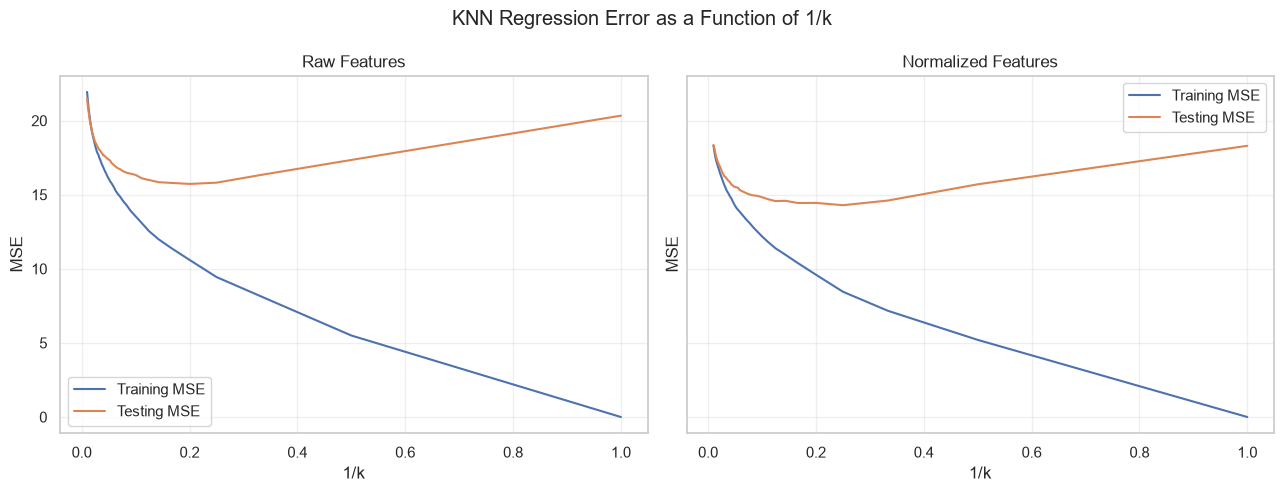

In [39]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    sharey=True
)

for ax, feature_type in zip(
    axes,
    feature_sets.keys()
):
    plot_data = (
        knn_results[
            knn_results["Feature Type"] == feature_type
        ]
        .sort_values("1/k")
    )
    
    ax.plot(
        plot_data["1/k"],
        plot_data["Training MSE"],
        label="Training MSE"
    )
    
    ax.plot(
        plot_data["1/k"],
        plot_data["Testing MSE"],
        label="Testing MSE"
    )
    
    ax.set_title(feature_type)
    ax.set_xlabel("1/k")
    ax.set_ylabel("MSE")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle(
    "KNN Regression Error as a Function of 1/k"
)

plt.tight_layout()
plt.show()

The best raw-feature model uses k = 5.  
The best normalized-feature model uses k = 4.  
Normalization lowers the test MSE because the predictors use different scales.

### 1(j) Comparison of KNN and Linear Regression

In [40]:
best_knn_feature_type = (
    best_knn_results["Testing MSE"].idxmin()
)

best_knn_model = best_knn_results.loc[
    best_knn_feature_type
]

final_model_comparison = pd.DataFrame({
    "Model": [
        "Selected Polynomial-Interaction Model",
        (
            f"{best_knn_feature_type} KNN "
            f"(k = {int(best_knn_model['k'])})"
        )
    ],
    "Training MSE": [
        improved_train_mse,
        best_knn_model["Training MSE"]
    ],
    "Testing MSE": [
        improved_test_mse,
        best_knn_model["Testing MSE"]
    ]
}).set_index("Model")

mse_reduction_percent = (
    (
        improved_test_mse
        - best_knn_model["Testing MSE"]
    )
    / improved_test_mse
    * 100
)

display(final_model_comparison.round(3))

print(
    "KNN test MSE reduction: "
    f"{mse_reduction_percent:.1f}%"
)

,Training MSE,Testing MSE
Model,,
Selected Polynomial-Interaction Model,17.891,18.660
Normalized Features KNN (k = 4),8.454,14.291


KNN test MSE reduction: 23.4%


The test MSE of the normalized KNN is lower: 14.291, which is approximately 23.4% lower than 18.660.
KNN can better capture local nonlinear structures, but the gap between the training set and the test set is larger.
Therefore, under this data division, KNN performs better in terms of prediction performance, while linear models are easier to interpret.

## 2. ISLR 2.4.1

### (a)

A flexible approach is expected to yield better results.
A larger sample size can reduce the risk of overfitting.

### (b)

A flexible method is expected to perform worse.
Due to the large number of predictor variables and the small number of observations, it is likely to suffer from overfitting.

### (c)

A flexible approach is expected to perform better.
It can represent highly nonlinear relationships.
### (d)

A flexible approach is expected to perform worse.
Due to the high variance of errors, it is more prone to fitting noise.

## 3. ISLR 2.4.7

The test point is $X_0=(0,0,0)$.

### (a)

The Euclidean distance is

$$
d(X_i,X_0)
=
\sqrt{
(X_{i1}-0)^2+
(X_{i2}-0)^2+
(X_{i3}-0)^2
}.
$$

| Observation | Distance |
|---|---:|
| 1 | $3$ |
| 2 | $2$ |
| 3 | $\sqrt{10} \approx 3.162$ |
| 4 | $\sqrt{5} \approx 2.236$ |
| 5 | $\sqrt{2} \approx 1.414$ |
| 6 | $\sqrt{3} \approx 1.732$ |

### (b)

For $K=1$, the prediction is Green.  
Observation 5 is the nearest neighbor.

### (c)

For $K=3$, the prediction is Red.  
The three nearest observations are 5, 6, and 2, with classes Green, Red, and Red.

### (d)

A small value of $K$ is preferred.  
A small $K$ produces a more flexible decision boundary that can represent strong nonlinearity.